In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"D:/FDSL/Student_Performance_Dataset.csv")

print("\n========== FIRST 5 RECORDS ==========")
print(df.head())

print("\n========== DATASET INFORMATION ==========")
print(df.info())

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())


========== FIRST 5 RECORDS ==========
  Student_ID  Age  Gender  Class  Study_Hours_Per_Day  Attendance_Percentage  \
0      S0001   15    Male     12                  1.0                     65   
1      S0002   19  Female      9                  1.6                     58   
2      S0003   14  Female     12                  3.6                     64   
3      S0004   18  Female      9                  5.5                     68   
4      S0005   14    Male     10                  5.0                     80   

  Parental_Education Internet_Access Extracurricular_Activities  Math_Score  \
0       Postgraduate              No                         No          40   
1           Graduate              No                        Yes          80   
2        High School             Yes                        Yes          83   
3       Postgraduate             Yes                         No          68   
4        High School             Yes                         No          41   

   Sc

In [9]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("\n========== NUMERIC COLUMNS ==========")
print(list(numeric_columns))


========== NUMERIC COLUMNS ==========
['Age', 'Class', 'Study_Hours_Per_Day', 'Attendance_Percentage', 'Math_Score', 'Science_Score', 'English_Score', 'Previous_Year_Score', 'Final_Percentage']


In [10]:
column = "Final_Percentage"

data = df[column].dropna()

print("\n==SELECTED COLUMN ==")
print(column)

print("\nNumber of observations:", len(data))


==SELECTED COLUMN ==
Final_Percentage

Number of observations: 5000


In [11]:
mean_value = data.mean()
median_value = data.median()
mode_value = data.mode()

print("\n== CENTRAL TENDENCY USING PANDAS ==")

print("Mean   :", round(mean_value, 2))
print("Median :", round(median_value, 2))
print("Mode   :", list(mode_value))


== CENTRAL TENDENCY USING PANDAS ==
Mean   : 67.48
Median : 67.33
Mode   : [66.33]


In [12]:
data_array = data.to_numpy()

numpy_mean = np.mean(data_array)
numpy_median = np.median(data_array)

print("\n==CENTRAL TENDENCY USING NUMPY ==")

print("NumPy Mean   :", round(numpy_mean, 2))
print("NumPy Median :", round(numpy_median, 2))



==CENTRAL TENDENCY USING NUMPY ==
NumPy Mean   : 67.48
NumPy Median : 67.33


In [13]:
print("\n**== CENTRAL TENDENCY FOR ALL NUMERIC COLUMNS ==**")

central_tendency = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Mode": df[numeric_columns].mode().iloc[0]
})

print(central_tendency)



**== CENTRAL TENDENCY FOR ALL NUMERIC COLUMNS ==**
                            Mean  Median   Mode
Age                    16.508800   17.00  18.00
Class                  10.496400   10.00  10.00
Study_Hours_Per_Day     3.287260    3.30   1.90
Attendance_Percentage  74.919800   75.00  97.00
Math_Score             67.754800   68.00  73.00
Science_Score          66.895400   67.00  37.00
English_Score          67.782800   68.00  99.00
Previous_Year_Score    67.282200   67.00  48.00
Final_Percentage       67.477656   67.33  66.33


In [14]:
skewness = data.skew()

print("\n========== SKEWNESS ==========")
print("Skewness:", round(skewness, 3))


if skewness > 0:
    print("Distribution is positively skewed (Right Skewed).")

elif skewness < 0:
    print("Distribution is negatively skewed (Left Skewed).")

else:
    print("Distribution is approximately symmetric.")


========== SKEWNESS ==========
Skewness: -0.018
Distribution is negatively skewed (Left Skewed).


In [15]:
print("\n========== MEAN VS MEDIAN ==========")

if mean_value > median_value:
    print("Mean > Median")
    print("The data may be right-skewed.")

elif mean_value < median_value:
    print("Mean < Median")
    print("The data may be left-skewed.")

else:
    print("Mean ≈ Median")
    print("The distribution is approximately symmetric.")


========== MEAN VS MEDIAN ==========
Mean > Median
The data may be right-skewed.


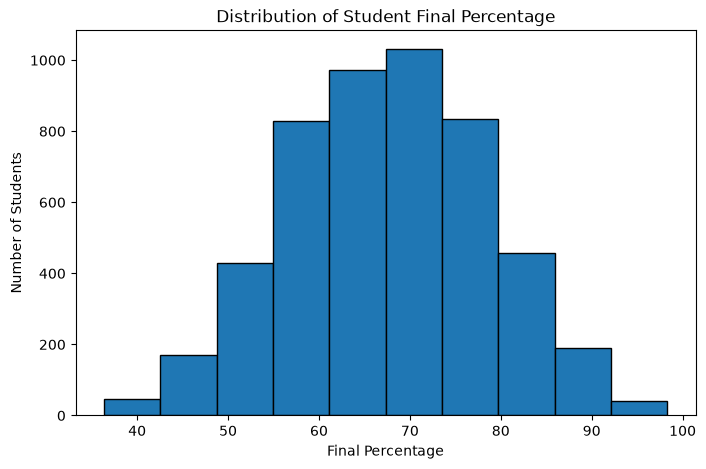

In [16]:
plt.figure(figsize=(8, 5))

plt.hist(data, bins=10, edgecolor="black")

plt.title("Distribution of Student Final Percentage")
plt.xlabel("Final Percentage")
plt.ylabel("Number of Students")

plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_6748\1040871210.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data, vert=False)


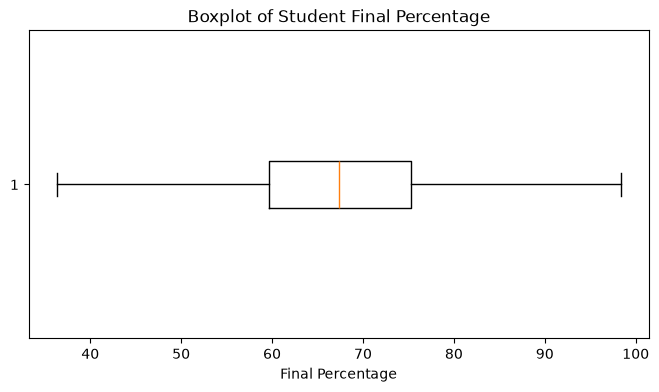

In [17]:
plt.figure(figsize=(8, 4))

plt.boxplot(data, vert=False)

plt.title("Boxplot of Student Final Percentage")
plt.xlabel("Final Percentage")

plt.show()

In [18]:
subjects = ["Math_Score", "Science_Score", "English_Score"]

print("\n========== SUBJECT-WISE CENTRAL TENDENCY ==========")

for subject in subjects:

    data = df[subject].dropna()

    print("\nSubject:", subject)
    print("Mean   :", round(data.mean(), 2))
    print("Median :", round(data.median(), 2))
    print("Mode   :", list(data.mode()))
    print("Skewness:", round(data.skew(), 3))


========== SUBJECT-WISE CENTRAL TENDENCY ==========

Subject: Math_Score
Mean   : 67.75
Median : 68.0
Mode   : [73, 79]
Skewness: -0.027

Subject: Science_Score
Mean   : 66.9
Median : 67.0
Mode   : [37]
Skewness: 0.044

Subject: English_Score
Mean   : 67.78
Median : 68.0
Mode   : [99]
Skewness: -0.022
